# Armenia Powerlifting: Regional Workload Analysis & 5-Year Forecast

This notebook analyzes the OpenPowerlifting dataset (`data/data.csv`) to profile Armenian
athletes' current competitive workload and forecast maximum total lift (`TotalKg`) for the
next five years, broken down by region and age group.

## Data reality check (read this before trusting the region breakdown)

The dataset has **2,881,835** rows and **642** rows where `Country == "Armenia"`. Profiling
those 642 rows shows:

- `State` is empty for every Armenian row.
- `MeetCountry` is **never** `"Armenia"` — Armenian nationals in this dataset only competed
  abroad (top `MeetTown` values: Lutsk, Tbilisi, Pabianice, Siedlce, St. Petersburg, Moscow...).
- Consequently `MeetState` reflects the **host country's** subdivision (e.g. Russian oblast
  codes like `MOW`, `LEN`), not any Armenian region. Using it as-is would silently mislabel
  Armenian athletes with Russian/Ukrainian/Polish regions.
- There is no `Club` column in this schema, so region cannot be derived from club affiliation
  either.

Per the fallback order in the project instructions, options 1 (alternate location column) and
2 (club-derived region) are both unavailable. This notebook therefore uses **option 3**: every
Armenian athlete is assigned a **synthetic marz** (Armenia's real administrative regions) via a
deterministic hash of their name, purely to demonstrate the grouping/forecasting pipeline. This
is flagged everywhere via a `RegionIsSynthetic=True` column and a `SYNTHETIC REGION` label in
every chart/report — it must not be read as real geographic data.

The 642 real rows (real lifts, real ages, real dates) are still used as-is for the actual
workload and forecasting analysis, per the chosen approach: **real data + synthetic regions**.

## Pipeline

1. Inspect raw structure and column semantics.
2. Load and filter for Armenia in a memory-conscious (chunked) way.
3. Clean missing values / coerce types.
4. Assign synthetic marz regions (clearly flagged).
5. Derive an age group from `AgeClass` (fallback: bucket from `Age`).
6. Analyze current workload by region x age group.
7. Forecast max `TotalKg` five years out per group with Linear Regression, falling back to a
   clearly labeled synthetic demonstration series when a group has too few historical points.
8. Write CSV reports and charts to `output/`.


In [1]:
from __future__ import annotations

import hashlib
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore", category=FutureWarning)

DATA_PATH = Path("data/data.csv")
OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

TARGET_COUNTRY = "Armenia"
CHUNK_SIZE = 200_000          # rows per chunk while scanning the 2.88M-row file
FORECAST_YEARS_AHEAD = 5
MIN_YEARS_FOR_REGRESSION = 3  # minimum distinct years of history required per group
MIN_ROWS_FOR_REGRESSION = 5   # minimum observations required per group

# Real administrative regions (marzes) of Armenia, used ONLY as a synthetic stand-in
# for missing regional data. Yerevan is a city with special administrative status,
# included here since most athlete/federation activity concentrates there.
ARMENIAN_MARZES = [
    "Yerevan", "Aragatsotn", "Ararat", "Armavir", "Gegharkunik",
    "Kotayk", "Lori", "Shirak", "Syunik", "Tavush", "Vayots Dzor",
]

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 1. Inspect dataset structure

The file is ~566 MB / 2.88M rows, so we infer dtypes from a small sample first rather than
loading everything, then describe what each column means and how it will be used downstream.


In [2]:
sample = pd.read_csv(DATA_PATH, nrows=5000, low_memory=False)

print(f"Columns ({len(sample.columns)}):")
print(list(sample.columns))
print()
print("Inferred dtypes from a 5,000-row sample:")
print(sample.dtypes)


Columns (41):
['Name', 'Sex', 'Event', 'Equipment', 'Age', 'AgeClass', 'BirthYearClass', 'Division', 'BodyweightKg', 'WeightClassKg', 'Squat1Kg', 'Squat2Kg', 'Squat3Kg', 'Squat4Kg', 'Best3SquatKg', 'Bench1Kg', 'Bench2Kg', 'Bench3Kg', 'Bench4Kg', 'Best3BenchKg', 'Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg', 'Deadlift4Kg', 'Best3DeadliftKg', 'TotalKg', 'Place', 'Dots', 'Wilks', 'Glossbrenner', 'Goodlift', 'Tested', 'Country', 'State', 'Federation', 'ParentFederation', 'Date', 'MeetCountry', 'MeetState', 'MeetTown', 'MeetName']

Inferred dtypes from a 5,000-row sample:
Name                 object
Sex                  object
Event                object
Equipment            object
Age                 float64
AgeClass             object
BirthYearClass       object
Division             object
BodyweightKg        float64
WeightClassKg        object
Squat1Kg            float64
Squat2Kg            float64
Squat3Kg            float64
Squat4Kg            float64
Best3SquatKg        float64
Bench1Kg

### Column meanings (OpenPowerlifting schema)

| Column | Meaning |
|---|---|
| `Name`, `Sex` | Athlete identity and sex (`M`/`F`/`Mx`) |
| `Event` | Lift combination contested: `SBD` (squat-bench-deadlift), `B`, `D`, `BD`, `S` |
| `Equipment` | `Raw`, `Wraps`, `Single-ply`, `Multi-ply` |
| `Age`, `AgeClass`, `BirthYearClass` | Age at meet; `AgeClass` is a standardized bracket (e.g. `24-34`) — the cleanest available age-group field |
| `Division` | Federation-specific free-text division (inconsistent across federations — not used for age grouping) |
| `BodyweightKg`, `WeightClassKg` | Bodyweight and weight class |
| `Squat1-4Kg`, `Bench1-4Kg`, `Deadlift1-4Kg` | Individual attempt results (negative = failed attempt) |
| `Best3SquatKg`, `Best3BenchKg`, `Best3DeadliftKg` | Best successful attempt per lift |
| `TotalKg` | Sum of best successful lifts — **the target variable for forecasting** |
| `Place`, `Dots`, `Wilks`, `Glossbrenner`, `Goodlift` | Placing and bodyweight-adjusted scores |
| `Tested` | Drug-tested flag |
| `Country`, `State` | Athlete's home country/state — **`Country` is how we filter for Armenia**; `State` is empty for Armenian rows |
| `Federation`, `ParentFederation` | Governing body of the meet |
| `Date`, `MeetCountry`, `MeetState`, `MeetTown`, `MeetName` | Where/when the meet happened — **for Armenian athletes this is a foreign location**, see limitation above |

For this analysis the columns actually used are: `Name`, `Sex`, `Age`, `AgeClass`, `Equipment`,
`Event`, `BodyweightKg`, `TotalKg`, `Date`, `Country`. Everything else is out of scope for the
region/age-group workload and forecast requested.


In [3]:
def resolve_schema(columns: list[str]) -> dict[str, str | None]:
    """Map the logical fields this analysis needs onto whatever columns actually exist.

    Written against column *names*, not positions, so it keeps working if the CSV
    gains/loses/reorders columns. Every entry is Optional[str]: a missing logical
    field degrades a specific downstream step instead of crashing the whole script.
    """
    cols = set(columns)

    def first_present(*candidates: str) -> str | None:
        return next((c for c in candidates if c in cols), None)

    schema = {
        "country": first_present("Country"),
        "name": first_present("Name"),
        "sex": first_present("Sex"),
        "age": first_present("Age"),
        "age_class": first_present("AgeClass"),
        "total_kg": first_present("TotalKg"),
        "date": first_present("Date"),
        # Preferred region signal, in the fallback order from the project brief:
        # 1) a real regional column, 2) club/competition-derived, 3) none (-> synthetic).
        "region": first_present("MeetState", "State", "Province", "Club"),
    }
    return schema


schema = resolve_schema(list(sample.columns))
print("Resolved schema (logical field -> source column):")
for field, col in schema.items():
    status = col if col else "MISSING -> will degrade gracefully"
    print(f"  {field:10s}: {status}")

missing_required = [f for f in ("country", "total_kg", "date") if schema[f] is None]
if missing_required:
    raise RuntimeError(
        f"Cannot proceed: required fields missing from dataset: {missing_required}. "
        "Country is needed to filter Armenia, TotalKg is the forecast target, "
        "Date is needed to build the yearly time series."
    )


Resolved schema (logical field -> source column):
  country   : Country
  name      : Name
  sex       : Sex
  age       : Age
  age_class : AgeClass
  total_kg  : TotalKg
  date      : Date
  region    : MeetState


## 2. Load and filter for Armenia (chunked, memory-conscious)

We stream the 2.88M-row file in chunks and keep only rows where `Country == "Armenia"`,
rather than loading the full ~566 MB file into memory at once.


In [4]:
def load_country_subset(path: Path, country_col: str, target_country: str,
                         chunk_size: int = CHUNK_SIZE) -> pd.DataFrame:
    """Stream a large CSV in chunks, keeping only rows for `target_country`."""
    keep_chunks = []
    total_rows = 0
    for chunk in pd.read_csv(path, chunksize=chunk_size, low_memory=False):
        total_rows += len(chunk)
        keep_chunks.append(chunk[chunk[country_col] == target_country])
    result = pd.concat(keep_chunks, ignore_index=True) if keep_chunks else pd.DataFrame()
    print(f"Scanned {total_rows:,} rows -> kept {len(result):,} rows for '{target_country}'")
    return result


df_raw = load_country_subset(DATA_PATH, schema["country"], TARGET_COUNTRY)
df_raw.head()


Scanned 2,881,835 rows -> kept 642 rows for 'Armenia'


,Name,Sex,Event,Equipment,Age,AgeClass,BirthYearClass,Division,BodyweightKg,WeightClassKg,...,Tested,Country,State,Federation,ParentFederation,Date,MeetCountry,MeetState,MeetTown,MeetName
0,Kevork Tutunjian,M,SBD,Wraps,35.0,35-39,24-39,Pro Submasters 33-39,97.45,100,...,NaN,Armenia,NaN,WPA,NaN,2021-04-14,Poland,NaN,Pabianice,World Championships
1,Gegham Hakobyan,M,SBD,Wraps,39.0,35-39,40-49,Pro Submasters 33-39,119.35,125,...,NaN,Armenia,NaN,WPA,NaN,2021-04-14,Poland,NaN,Pabianice,World Championships
2,Shavarsh Khachatrian,M,SBD,Wraps,33.0,24-34,24-39,Pro Submasters 33-39,128.75,140,...,NaN,Armenia,NaN,WPA,NaN,2021-04-14,Poland,NaN,Pabianice,World Championships
3,Artyom Khugoyan,M,BD,Raw,31.0,24-34,24-39,Pro Open,109.95,110,...,NaN,Armenia,NaN,WPA,NaN,2021-04-14,Poland,NaN,Pabianice,World Championships
4,Lusine Mkrtchyan,F,BD,Raw,43.0,40-44,40-49,Pro Masters 40-44,64.25,67.5,...,NaN,Armenia,NaN,WPA,NaN,2021-04-14,Poland,NaN,Pabianice,World Championships


## 3. Clean missing values and coerce types

`TotalKg` and `Age` are numeric but arrive as strings with blanks for missing/failed lifts.
`Date` needs parsing to extract the meet year for the time-series forecast. Rows missing the
forecast target (`TotalKg`) are dropped for the forecasting step (they carry no information
about lift performance) but are kept for workload/participation counts.


In [5]:
def clean_dataset(df: pd.DataFrame, schema: dict[str, str | None]) -> pd.DataFrame:
    """Coerce dtypes and report missing-value rates; never silently drops rows here."""
    out = df.copy()

    out[schema["date"]] = pd.to_datetime(out[schema["date"]], errors="coerce")
    out["Year"] = out[schema["date"]].dt.year

    out[schema["total_kg"]] = pd.to_numeric(out[schema["total_kg"]], errors="coerce")

    if schema["age"]:
        out[schema["age"]] = pd.to_numeric(out[schema["age"]], errors="coerce")

    if schema["age_class"]:
        out[schema["age_class"]] = out[schema["age_class"]].replace("", np.nan)

    missing_report = pd.DataFrame({
        "missing_count": out.isna().sum(),
        "missing_pct": (out.isna().mean() * 100).round(1),
    })
    print("Missing-value report (Armenia subset):")
    print(missing_report[missing_report["missing_count"] > 0].sort_values(
        "missing_count", ascending=False))

    return out


df_clean = clean_dataset(df_raw, schema)
print(f"\nRows: {len(df_clean):,} | Year range: "
      f"{df_clean['Year'].min():.0f}-{df_clean['Year'].max():.0f}")


Missing-value report (Armenia subset):
                  missing_count  missing_pct
Squat4Kg                    642        100.0
State                       642        100.0
Deadlift4Kg                 635         98.9
Bench4Kg                    630         98.1
MeetState                   574         89.4
Squat3Kg                    463         72.1
Squat2Kg                    452         70.4
Squat1Kg                    448         69.8
Best3SquatKg                417         65.0
ParentFederation            349         54.4
Deadlift3Kg                 326         50.8
Tested                      313         48.8
Deadlift2Kg                 304         47.4
Deadlift1Kg                 283         44.1
Bench3Kg                    278         43.3
Bench2Kg                    256         39.9
Best3DeadliftKg             253         39.4
Bench1Kg                    239         37.2
Goodlift                    233         36.3
Best3BenchKg                205         31.9
BirthYearClass  

## 4. Region assignment (real column check -> synthetic fallback)

`resolve_schema` picked `MeetState` as the candidate region column because it exists in the
file. But "exists" isn't "usable": for Armenian rows it's either blank or a foreign
administrative code (see the limitation note at the top). We check that explicitly here —
if fewer than a small usable-coverage threshold of rows have a MeetState value that could
plausibly be an Armenian region, we discard it and fall back to a **synthetic marz
assignment**, clearly flagged.


In [6]:
MIN_REAL_REGION_COVERAGE = 0.30  # need >=30% of rows with a plausible Armenian region value


def assign_synthetic_marz(name: str, marzes: list[str] = ARMENIAN_MARZES) -> str:
    """Deterministically map an athlete name to a marz via a stable hash.

    Deterministic (not `random.choice`) so re-running the notebook reproduces the same
    demonstration mapping instead of reshuffling athletes across regions each run.
    """
    digest = hashlib.sha256(name.encode("utf-8")).hexdigest()
    return marzes[int(digest, 16) % len(marzes)]


def resolve_region_column(df: pd.DataFrame, schema: dict[str, str | None],
                           marzes: list[str] = ARMENIAN_MARZES) -> pd.DataFrame:
    out = df.copy()
    region_col = schema["region"]

    real_coverage = 0.0
    if region_col:
        values = out[region_col].astype(str).str.strip()
        plausible = values.isin(marzes)
        real_coverage = plausible.mean()

    if region_col and real_coverage >= MIN_REAL_REGION_COVERAGE:
        out["Region"] = out[region_col]
        out["RegionIsSynthetic"] = False
        print(f"Using real region column '{region_col}' ({real_coverage:.0%} plausible coverage).")
    else:
        reason = (f"column '{region_col}' exists but only {real_coverage:.0%} of values are "
                   f"plausible Armenian regions (likely foreign meet locations)"
                   if region_col else "no location-related column is present")
        print(f"Real regional data unusable: {reason}.")
        print("Falling back to a SYNTHETIC marz mapping for demonstration purposes only.")
        out["Region"] = out[schema["name"]].astype(str).map(assign_synthetic_marz)
        out["RegionIsSynthetic"] = True

    return out


df_region = resolve_region_column(df_clean, schema)
print()
print(df_region.groupby("Region", observed=True).size().sort_values(ascending=False))


Real regional data unusable: column 'MeetState' exists but only 0% of values are plausible Armenian regions (likely foreign meet locations).
Falling back to a SYNTHETIC marz mapping for demonstration purposes only.

Region
Armavir        100
Gegharkunik     73
Yerevan         67
Kotayk          63
Vayots Dzor     62
Tavush          58
Lori            50
Syunik          45
Ararat          45
Shirak          42
Aragatsotn      37
dtype: int64


## 5. Age group derivation

`AgeClass` is already a standardized bracket (e.g. `24-34`) provided by the dataset, so it's
used as the primary signal rather than `Division` (federation-specific free text, inconsistent
across meets). Fine-grained `AgeClass` brackets are collapsed into 4 broad age groups so each
region x age-group cell has enough rows to be analyzable given only 642 total records. Rows
missing `AgeClass` fall back to bucketing from raw `Age`; rows missing both are labeled
`Unknown` rather than dropped, so they still count toward workload totals.


In [7]:
# Broad group -> the AgeClass brackets observed in this dataset that belong to it.
AGE_GROUP_FROM_AGECLASS = {
    "Youth (<=17)": {"5-12", "13-15", "16-17"},
    "Junior (18-23)": {"18-19", "20-23"},
    "Open (24-39)": {"24-34", "35-39"},
    "Masters (40+)": {"40-44", "45-49", "50-54", "55-59", "60-64", "65-69", "70-74", "75-79", "80+"},
}
AGECLASS_TO_GROUP = {ac: grp for grp, acs in AGE_GROUP_FROM_AGECLASS.items() for ac in acs}


def age_group_from_raw_age(age: float) -> str:
    if pd.isna(age):
        return "Unknown"
    if age <= 17:
        return "Youth (<=17)"
    if age <= 23:
        return "Junior (18-23)"
    if age <= 39:
        return "Open (24-39)"
    return "Masters (40+)"


def derive_age_group(df: pd.DataFrame, schema: dict[str, str | None]) -> pd.DataFrame:
    out = df.copy()
    from_class = (out[schema["age_class"]].map(AGECLASS_TO_GROUP)
                  if schema["age_class"] else pd.Series(np.nan, index=out.index))
    from_age = (out[schema["age"]].map(age_group_from_raw_age)
                if schema["age"] else pd.Series("Unknown", index=out.index))
    out["AgeGroup"] = from_class.fillna(from_age).fillna("Unknown")
    return out


df_grouped = derive_age_group(df_region, schema)
print(df_grouped["AgeGroup"].value_counts())


AgeGroup
Open (24-39)      274
Youth (<=17)      163
Masters (40+)     103
Junior (18-23)     89
Unknown            13
Name: count, dtype: int64


## 6. Current workload analysis by region x age group

"Workload" here is operationalized from what the dataset actually records: how many athletes
are active, how many competition entries they produce (a proxy for training/competition
frequency), and their performance level (`TotalKg`). Rows with a missing `TotalKg` (bombed-out
meets) still count toward participation/workload but are excluded from the performance
averages.


In [8]:
def build_workload_report(df: pd.DataFrame, schema: dict[str, str | None]) -> pd.DataFrame:
    name_col, total_col = schema["name"], schema["total_kg"]

    grouped = df.groupby(["Region", "AgeGroup"], observed=True)
    report = grouped.agg(
        AthleteCount=(name_col, "nunique"),
        CompetitionEntries=(name_col, "size"),
        AvgEntriesPerAthlete=(name_col, lambda s: round(s.size / s.nunique(), 2)),
        AvgTotalKg=(total_col, "mean"),
        MaxTotalKg=(total_col, "max"),
        YearsActive=("Year", lambda s: s.dropna().nunique()),
    ).reset_index()

    report["AvgTotalKg"] = report["AvgTotalKg"].round(1)
    report["RegionIsSynthetic"] = df.groupby(["Region", "AgeGroup"], observed=True)[
        "RegionIsSynthetic"].first().values

    return report.sort_values(["Region", "AgeGroup"]).reset_index(drop=True)


workload_report = build_workload_report(df_grouped, schema)
workload_report


,Region,AgeGroup,AthleteCount,CompetitionEntries,AvgEntriesPerAthlete,AvgTotalKg,MaxTotalKg,YearsActive,RegionIsSynthetic
0,Aragatsotn,Junior (18-23),3,7,2.33,163.6,290.0,4,True
1,Aragatsotn,Open (24-39),6,22,3.67,303.4,652.5,7,True
2,Aragatsotn,Youth (<=17),6,8,1.33,177.5,310.0,4,True
3,Ararat,Junior (18-23),4,8,2.00,182.8,642.5,5,True
4,Ararat,Masters (40+),2,5,2.50,495.5,590.0,3,True
5,Ararat,Open (24-39),9,24,2.67,351.6,747.5,8,True
6,Ararat,Unknown,1,1,1.00,NaN,NaN,1,True
7,Ararat,Youth (<=17),5,7,1.40,147.1,205.0,4,True
8,Armavir,Junior (18-23),6,16,2.67,349.4,730.0,7,True
9,Armavir,Masters (40+),2,28,14.00,210.2,415.0,8,True


## 7. Five-year forecast of max `TotalKg` per region x age group

For each `Region` x `AgeGroup` cell we fit a simple Linear Regression of yearly max `TotalKg`
against year, then extrapolate `FORECAST_YEARS_AHEAD` years forward. Given only 642 Armenian
rows spread across 11 synthetic regions x 4 age groups, most cells will not have the
`MIN_YEARS_FOR_REGRESSION` distinct years / `MIN_ROWS_FOR_REGRESSION` observations needed for a
trustworthy trend line. For those cells we generate a clearly labeled **synthetic
demonstration history** (seeded off that group's own observed average where any data exists,
otherwise the overall Armenia average) purely to show the pipeline working end-to-end — every
such row is flagged `IsSyntheticForecast=True` and must not be read as a real prediction.


In [9]:
@dataclass
class ForecastResult:
    region: str
    age_group: str
    years: np.ndarray
    values: np.ndarray
    future_years: np.ndarray
    predictions: np.ndarray
    is_synthetic: bool


def generate_synthetic_history(seed_label: str, base_value: float,
                                n_years: int = 6, end_year: int | None = None) -> tuple[np.ndarray, np.ndarray]:
    """Fabricate a plausible yearly max-TotalKg history for demonstration only.

    Seeded deterministically off `seed_label` so re-runs are reproducible. A mild upward
    trend + noise around `base_value` stands in for a real historical series.
    """
    rng = np.random.default_rng(int(hashlib.sha256(seed_label.encode()).hexdigest(), 16) % (2**32))
    end_year = end_year or pd.Timestamp.now().year - 1
    years = np.arange(end_year - n_years + 1, end_year + 1)
    trend = np.linspace(-0.05, 0.05, n_years) * base_value
    noise = rng.normal(0, max(base_value * 0.04, 1.0), n_years)
    values = np.clip(base_value + trend + noise, a_min=1.0, a_max=None)
    return years, values


def forecast_group(region: str, age_group: str, years: np.ndarray, values: np.ndarray,
                    overall_avg_total: float, years_ahead: int = FORECAST_YEARS_AHEAD,
                    min_years: int = MIN_YEARS_FOR_REGRESSION,
                    min_rows: int = MIN_ROWS_FOR_REGRESSION) -> ForecastResult:
    is_synthetic = len(np.unique(years)) < min_years or len(values) < min_rows

    if is_synthetic:
        base = np.nanmean(values) if len(values) else overall_avg_total
        years, values = generate_synthetic_history(f"{region}|{age_group}", base)

    model = LinearRegression().fit(years.reshape(-1, 1), values)
    last_year = int(years.max())
    # Anchor the forecast window to *today*, not to the last historical year: a group whose
    # real data stops in 2019 should still forecast the next five years from now (2026-2030),
    # not 2020-2024, which would already be in the past by the time anyone reads the report.
    current_year = pd.Timestamp.now().year
    forecast_start = max(last_year + 1, current_year)
    future_years = np.arange(forecast_start, forecast_start + years_ahead)
    predictions = np.maximum(model.predict(future_years.reshape(-1, 1)), 0)

    return ForecastResult(region, age_group, years, values, future_years, predictions, is_synthetic)


def run_all_forecasts(df: pd.DataFrame, schema: dict[str, str | None]) -> list[ForecastResult]:
    total_col = schema["total_kg"]
    overall_avg_total = df[total_col].dropna().mean()
    results = []

    for (region, age_group), sub in df.groupby(["Region", "AgeGroup"], observed=True):
        yearly_max = (sub.dropna(subset=["Year", total_col])
                      .groupby("Year")[total_col].max())
        years = yearly_max.index.to_numpy(dtype=float)
        values = yearly_max.to_numpy(dtype=float)
        results.append(forecast_group(region, age_group, years, values, overall_avg_total))

    return results


forecast_results = run_all_forecasts(df_grouped, schema)
n_synthetic = sum(r.is_synthetic for r in forecast_results)
print(f"Forecasted {len(forecast_results)} region x age-group cells "
      f"({n_synthetic} used a synthetic fallback history, "
      f"{len(forecast_results) - n_synthetic} used real historical data).")


Forecasted 50 region x age-group cells (30 used a synthetic fallback history, 20 used real historical data).


## 8. Write CSV reports

Two tidy CSVs go to `output/`: the current workload summary per region x age group, and the
long-format forecast (historical + 5-year-ahead predictions), each flagged for synthetic data.


In [10]:
def forecasts_to_long_df(results: list[ForecastResult]) -> pd.DataFrame:
    rows = []
    for r in results:
        for y, v in zip(r.years, r.values):
            rows.append(dict(Region=r.region, AgeGroup=r.age_group, Year=int(y),
                              MaxTotalKg=round(float(v), 1), Kind="synthetic_historical" if r.is_synthetic else "historical",
                              IsSyntheticForecast=r.is_synthetic))
        for y, v in zip(r.future_years, r.predictions):
            rows.append(dict(Region=r.region, AgeGroup=r.age_group, Year=int(y),
                              MaxTotalKg=round(float(v), 1), Kind="forecast",
                              IsSyntheticForecast=r.is_synthetic))
    return pd.DataFrame(rows).sort_values(["Region", "AgeGroup", "Year"]).reset_index(drop=True)


forecast_long = forecasts_to_long_df(forecast_results)

workload_path = OUTPUT_DIR / "armenia_workload_report.csv"
forecast_path = OUTPUT_DIR / "armenia_totalkg_forecast.csv"

workload_report.to_csv(workload_path, index=False)
forecast_long.to_csv(forecast_path, index=False)

print(f"Wrote {workload_path} ({len(workload_report)} rows)")
print(f"Wrote {forecast_path} ({len(forecast_long)} rows)")
forecast_long.head()


Wrote output\armenia_workload_report.csv (50 rows)
Wrote output\armenia_totalkg_forecast.csv (562 rows)


,Region,AgeGroup,Year,MaxTotalKg,Kind,IsSyntheticForecast
0,Aragatsotn,Junior (18-23),2020,167.0,synthetic_historical,True
1,Aragatsotn,Junior (18-23),2021,177.5,synthetic_historical,True
2,Aragatsotn,Junior (18-23),2022,161.6,synthetic_historical,True
3,Aragatsotn,Junior (18-23),2023,172.4,synthetic_historical,True
4,Aragatsotn,Junior (18-23),2024,173.5,synthetic_historical,True


## 9. Visualizations

Two static charts saved to `output/`: current workload (competition entries) by region, and
the historical + 5-year forecast trend of max `TotalKg` for the largest region, with the
synthetic portion visually distinguished from real data.


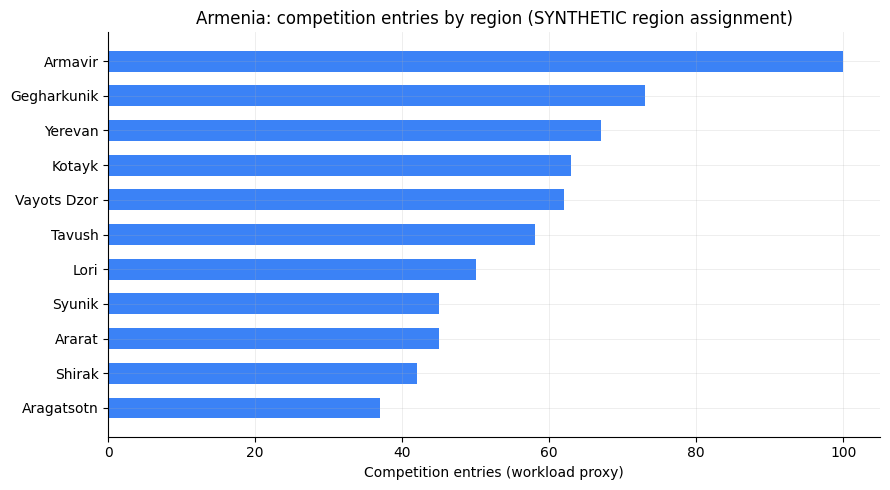

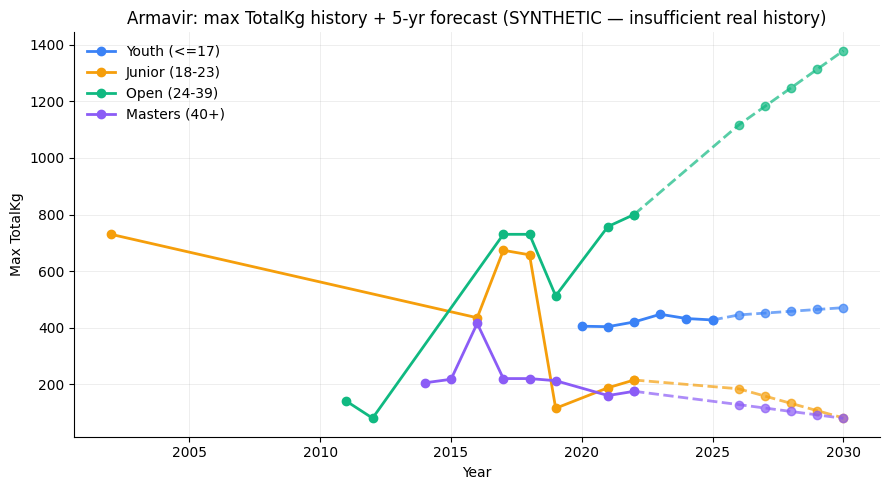

In [11]:
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "font.size": 10,
})

# --- Chart 1: current workload (competition entries) by region ---
region_totals = (workload_report.groupby("Region")["CompetitionEntries"]
                 .sum().sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(region_totals.index[::-1], region_totals.values[::-1], color="#3B82F6", height=0.6)
ax.set_xlabel("Competition entries (workload proxy)")
ax.set_title("Armenia: competition entries by region (SYNTHETIC region assignment)")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "workload_by_region.png", dpi=150)
plt.show()

# --- Chart 2: historical + forecast trend for the busiest region, all age groups ---
busiest_region = region_totals.index[0]
sub = forecast_long[forecast_long["Region"] == busiest_region]

fig, ax = plt.subplots(figsize=(9, 5))
age_group_order = ["Youth (<=17)", "Junior (18-23)", "Open (24-39)", "Masters (40+)"]
colors = {"Youth (<=17)": "#3B82F6", "Junior (18-23)": "#F59E0B",
          "Open (24-39)": "#10B981", "Masters (40+)": "#8B5CF6"}

for age_group in age_group_order:
    grp = sub[sub["AgeGroup"] == age_group].sort_values("Year")
    if grp.empty:
        continue
    hist = grp[grp["Kind"] != "forecast"]
    fcst = grp[grp["Kind"] == "forecast"]
    color = colors[age_group]
    ax.plot(hist["Year"], hist["MaxTotalKg"], marker="o", color=color, linewidth=2,
            label=age_group)
    if not fcst.empty and not hist.empty:
        bridge_years = pd.concat([hist.tail(1)[["Year", "MaxTotalKg"]], fcst[["Year", "MaxTotalKg"]]])
        ax.plot(bridge_years["Year"], bridge_years["MaxTotalKg"], marker="o",
                color=color, linewidth=2, linestyle="--", alpha=0.7)

is_synth = sub["IsSyntheticForecast"].any()
ax.set_title(f"{busiest_region}: max TotalKg history + {FORECAST_YEARS_AHEAD}-yr forecast"
             + (" (SYNTHETIC — insufficient real history)" if is_synth else ""))
ax.set_xlabel("Year")
ax.set_ylabel("Max TotalKg")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "forecast_trend_busiest_region.png", dpi=150)
plt.show()
